<a href="https://colab.research.google.com/github/bharath-0905/mlproject/blob/main/dbscan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
os.environ['KAGGLE_USERNAME']="Bharath20"
os.environ['kaggle_key']="KGAT_10c8f629b88da2dac16c940f033b02cc"

In [ ]:
!kaggle datasets download -d ankit8467/dataset-for-dbscan

Dataset URL: https://www.kaggle.com/datasets/ankit8467/dataset-for-dbscan
License(s): unknown
dataset-for-dbscan.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
import zipfile
import os

zip_path="/content/dataset-for-dbscan.zip"
extract_path="extracted_file"

os.makedirs(extract_path,exist_ok=True)

with  zipfile.ZipFile(zip_path,'r')as zip_ref:
  zip_ref.extractall(extract_path)

print("File exctracted to:",extract_path)



File exctracted to: extracted_file


In [ ]:
#import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
#step 2: Load Dataset
data= pd.read_csv("/content/extracted_file/Clustering_gmm (2).csv")
print("First 5 rows:\n",data.head())

First 5 rows:
       Weight      Height
0  67.062924  176.086355
1  68.804094  178.388669
2  60.930863  170.284496
3  59.733843  168.691992
4  65.431230  173.763679


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Weight  500 non-null    float64
 1   Height  500 non-null    float64
dtypes: float64(2)
memory usage: 7.9 KB


In [ ]:
print("Rows :",data.shape[0])
print("columns :",data.shape[1])

Rows : 500
columns : 2


In [ ]:
print("Rows :",data.shape[0])
print("columns :",data.shape[1])

Rows : 500
columns : 2


In [ ]:
#Missing values

print(data.isnull().sum())

Weight    0
Height    0
dtype: int64


In [ ]:
print("Duplicate Rows:",data.duplicated().sum())

Duplicate Rows: 0


In [ ]:
x=data[['Weight','Height']]
print(x.head())

      Weight      Height
0  67.062924  176.086355
1  68.804094  178.388669
2  60.930863  170.284496
3  59.733843  168.691992
4  65.431230  173.763679


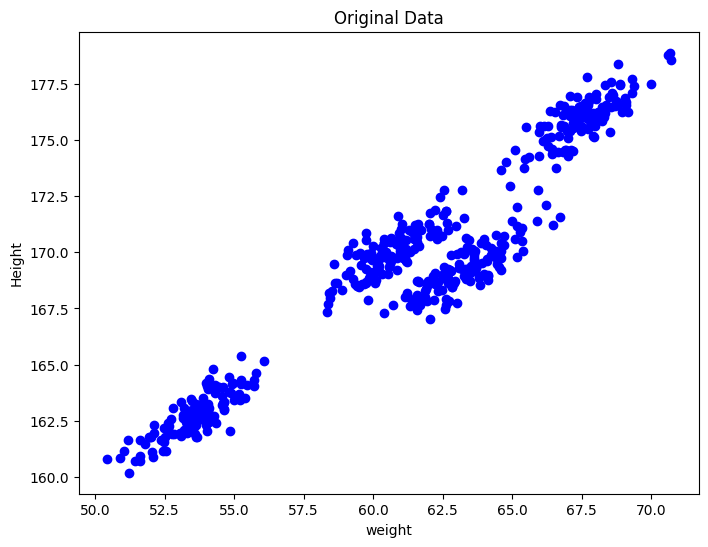

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    x['Weight'],
    x['Height'],
    color='blue'
)

plt.title('Original Data')
plt.xlabel("weight")
plt.ylabel("Height")

plt.show()


In [ ]:
scaler = StandardScaler()
x_scaled=scaler.fit_transform(x)

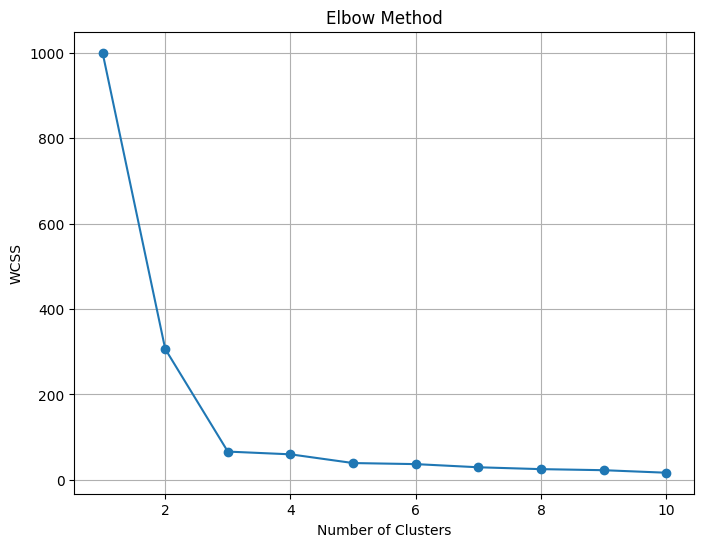

In [ ]:
# ==========================================
# Step 13: Elbow Method
# ==========================================

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(x_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,6))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

In [ ]:
# ==========================================
# Step 14: Train KMeans Model
# ==========================================

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(x_scaled)

In [ ]:
# ==========================================
# Step 15: Add Cluster Column
# ==========================================

data["Cluster"] = clusters

print(data.head())

      Weight      Height  Cluster
0  67.062924  176.086355        0
1  68.804094  178.388669        0
2  60.930863  170.284496        2
3  59.733843  168.691992        2
4  65.431230  173.763679        0


In [ ]:
# ==========================================
# Step 16: Cluster Centers
# ==========================================

centers = scaler.inverse_transform(kmeans.cluster_centers_)

print(centers)

[[ 67.48841925 175.89645403]
 [ 53.60029808 162.76478198]
 [ 61.92941241 169.62569396]]


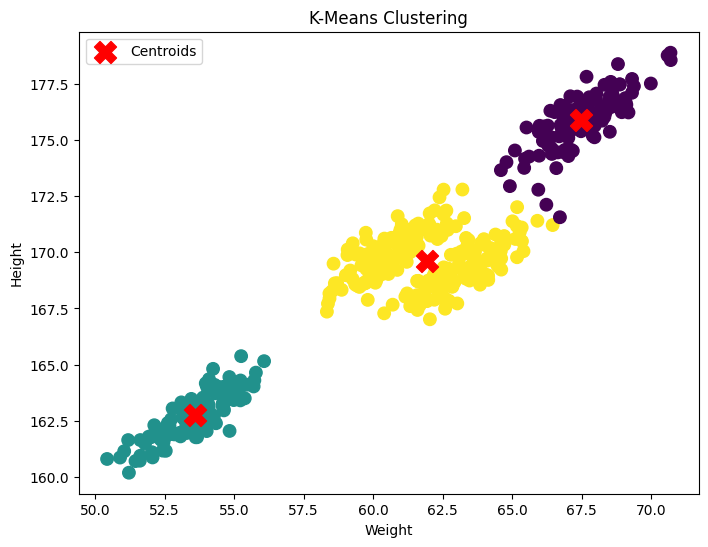

In [ ]:
# ==========================================
# Step 17: Cluster Visualization
# ==========================================

plt.figure(figsize=(8,6))

plt.scatter(
    data["Weight"],
    data["Height"],
    c=data["Cluster"],
    cmap="viridis",
    s=80
)

plt.scatter(
    centers[:,0],
    centers[:,1],
    color="red",
    marker="X",
    s=250,
    label="Centroids"
)

plt.title("K-Means Clustering")

plt.xlabel("Weight")

plt.ylabel("Height")

plt.legend()

plt.show()

In [ ]:
# ==========================================
# Step 18: Cluster Counts
# ==========================================

print(data["Cluster"].value_counts())

Cluster
2    247
0    128
1    125
Name: count, dtype: int64


In [ ]:
# ==========================================
# Step 19: Final Dataset
# ==========================================

data

,Weight,Height,Cluster
0,67.062924,176.086355,0
1,68.804094,178.388669,0
2,60.930863,170.284496,2
3,59.733843,168.691992,2
4,65.431230,173.763679,0
...,...,...,...
495,59.976983,169.679741,2
496,66.423814,174.625574,0
497,53.604698,161.919208,1
498,50.433644,160.794875,1


In [ ]:
from sklearn.metrics import silhouette_score

In [ ]:
# ==========================================
# Step 15: Calculate Silhouette Score
# ==========================================

score = silhouette_score(x_scaled, clusters)

print("Silhouette Score :", round(score, 3))

Silhouette Score : 0.736


In [ ]:
# ==========================================
# Find Best K using Silhouette Score
# ==========================================

from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = model.fit_predict(x_scaled)

    score = silhouette_score(x_scaled, labels)

    silhouette_scores.append(score)

    print(f"K = {k}  --->  Silhouette Score = {score:.3f}")

K = 2  --->  Silhouette Score = 0.662
K = 3  --->  Silhouette Score = 0.736
K = 4  --->  Silhouette Score = 0.632
K = 5  --->  Silhouette Score = 0.503
K = 6  --->  Silhouette Score = 0.513
K = 7  --->  Silhouette Score = 0.506
K = 8  --->  Silhouette Score = 0.503
K = 9  --->  Silhouette Score = 0.513
K = 10  --->  Silhouette Score = 0.455
